In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Carica dati europei già scaricati
returns_eu = pd.read_csv(
    r'C:\Users\ffran\monte-carlo-sim\data\raw\returns_europe.csv',
    index_col=0, parse_dates=True
)

# Usa STOXX come proxy di mercato — media equally weighted
market_returns = returns_eu.mean(axis=1)
market_returns.name = 'Market'

# Feature engineering per il regime detection
features = pd.DataFrame(index=market_returns.index)
features['returns']      = market_returns
features['vol_21']       = market_returns.rolling(21).std() * np.sqrt(252)
features['vol_63']       = market_returns.rolling(63).std() * np.sqrt(252)
features['momentum_21']  = market_returns.rolling(21).sum()
features['momentum_63']  = market_returns.rolling(63).sum()
features['drawdown']     = (market_returns.cumsum() - market_returns.cumsum().cummax())
features = features.dropna()

print(f"Feature matrix: {features.shape}")
print(f"Periodo: {features.index[0].date()} — {features.index[-1].date()}")
print(f"\nStatistiche descrittive:")
print(features.describe().round(4))

Feature matrix: (2762, 6)
Periodo: 2015-04-02 — 2025-12-31

Statistiche descrittive:
         returns     vol_21     vol_63  momentum_21  momentum_63   drawdown
count  2762.0000  2762.0000  2762.0000    2762.0000    2762.0000  2762.0000
mean      0.0004     0.1454     0.1512       0.0090       0.0279    -0.0427
std       0.0106     0.0846     0.0743       0.0472       0.0694     0.0536
min      -0.1241     0.0433     0.0632      -0.4289      -0.3909    -0.4365
25%      -0.0041     0.0935     0.1050      -0.0127      -0.0062    -0.0613
50%       0.0009     0.1229     0.1239       0.0120       0.0321    -0.0226
75%       0.0054     0.1692     0.1816       0.0348       0.0692    -0.0057
max       0.0993     0.7633     0.5144       0.1963       0.3316     0.0000


In [ ]:
from hmmlearn.hmm import GaussianHMM

# Prepara feature per HMM — usa returns e volatilità realizzata
X_hmm = features[['returns', 'vol_21']].values

# HMM con 4 stati latenti
hmm_model = GaussianHMM(
    n_components=4,
    covariance_type='diag',
    n_iter=1000,
    random_state=42
)
hmm_model.fit(X_hmm)

# Predici la sequenza di regimi
hmm_states = hmm_model.predict(X_hmm)
features['hmm_state'] = hmm_states

# Statistiche per stato HMM
hmm_stats = features.groupby('hmm_state').agg(
    giorni=('returns', 'count'),
    return_annuo=('returns', lambda x: x.mean() * 252),
    vol_media=('vol_21', 'mean'),
    sharpe=('returns', lambda x: (x.mean() * 252) / (x.std() * np.sqrt(252)))
).round(3)

print("Statistiche HMM per stato latente:")
print(hmm_stats)

# Matrice di transizione
print("\nMatrice di transizione (probabilità):")
print(pd.DataFrame(
    hmm_model.transmat_.round(3),
    index=[f'Da Stato {i}' for i in range(4)],
    columns=[f'A Stato {i}' for i in range(4)]
))

Model is not converging.  Current: 15812.668334624374 is not greater than 15812.769646332299. Delta is -0.10131170792556077


Statistiche HMM per stato latente:
           giorni  return_annuo  vol_media  sharpe
hmm_state                                         
0             516        -0.020      0.185  -0.106
1            1084         0.089      0.086   0.978
2             309         0.063      0.330   0.184
3             853         0.227      0.130   1.793

Matrice di transizione (probabilità):
            A Stato 0  A Stato 1  A Stato 2  A Stato 3
Da Stato 0      0.948      0.000      0.020      0.032
Da Stato 1      0.002      0.974      0.000      0.024
Da Stato 2      0.029      0.000      0.967      0.003
Da Stato 3      0.018      0.035      0.000      0.947


In [6]:
# Labeling basato su statistiche emergenti — non ex post snooping
state_names = {0: 'BEAR', 1: 'CHOP', 2: 'HIGH-VOL', 3: 'BULL'}
features['hmm_regime'] = features['hmm_state'].map(state_names)

print("Conteggio giorni per regime HMM:")
print(features['hmm_regime'].value_counts())

# Statistiche finali pulite
print("\nStatistiche annualizzate per regime:")
print(features.groupby('hmm_regime').agg(
    giorni=('returns', 'count'),
    return_annuo=('returns', lambda x: round(x.mean() * 252 * 100, 1)),
    vol_media=('vol_21', lambda x: round(x.mean() * 100, 1)),
    sharpe=('returns', lambda x: round((x.mean() * 252) / (x.std() * np.sqrt(252)), 2))
))

Conteggio giorni per regime HMM:
hmm_regime
CHOP        1084
BULL         853
BEAR         516
HIGH-VOL     309
Name: count, dtype: int64

Statistiche annualizzate per regime:
            giorni  return_annuo  vol_media  sharpe
hmm_regime                                         
BEAR           516          -2.0       18.5   -0.11
BULL           853          22.7       13.0    1.79
CHOP          1084           8.9        8.6    0.98
HIGH-VOL       309           6.3       33.0    0.18


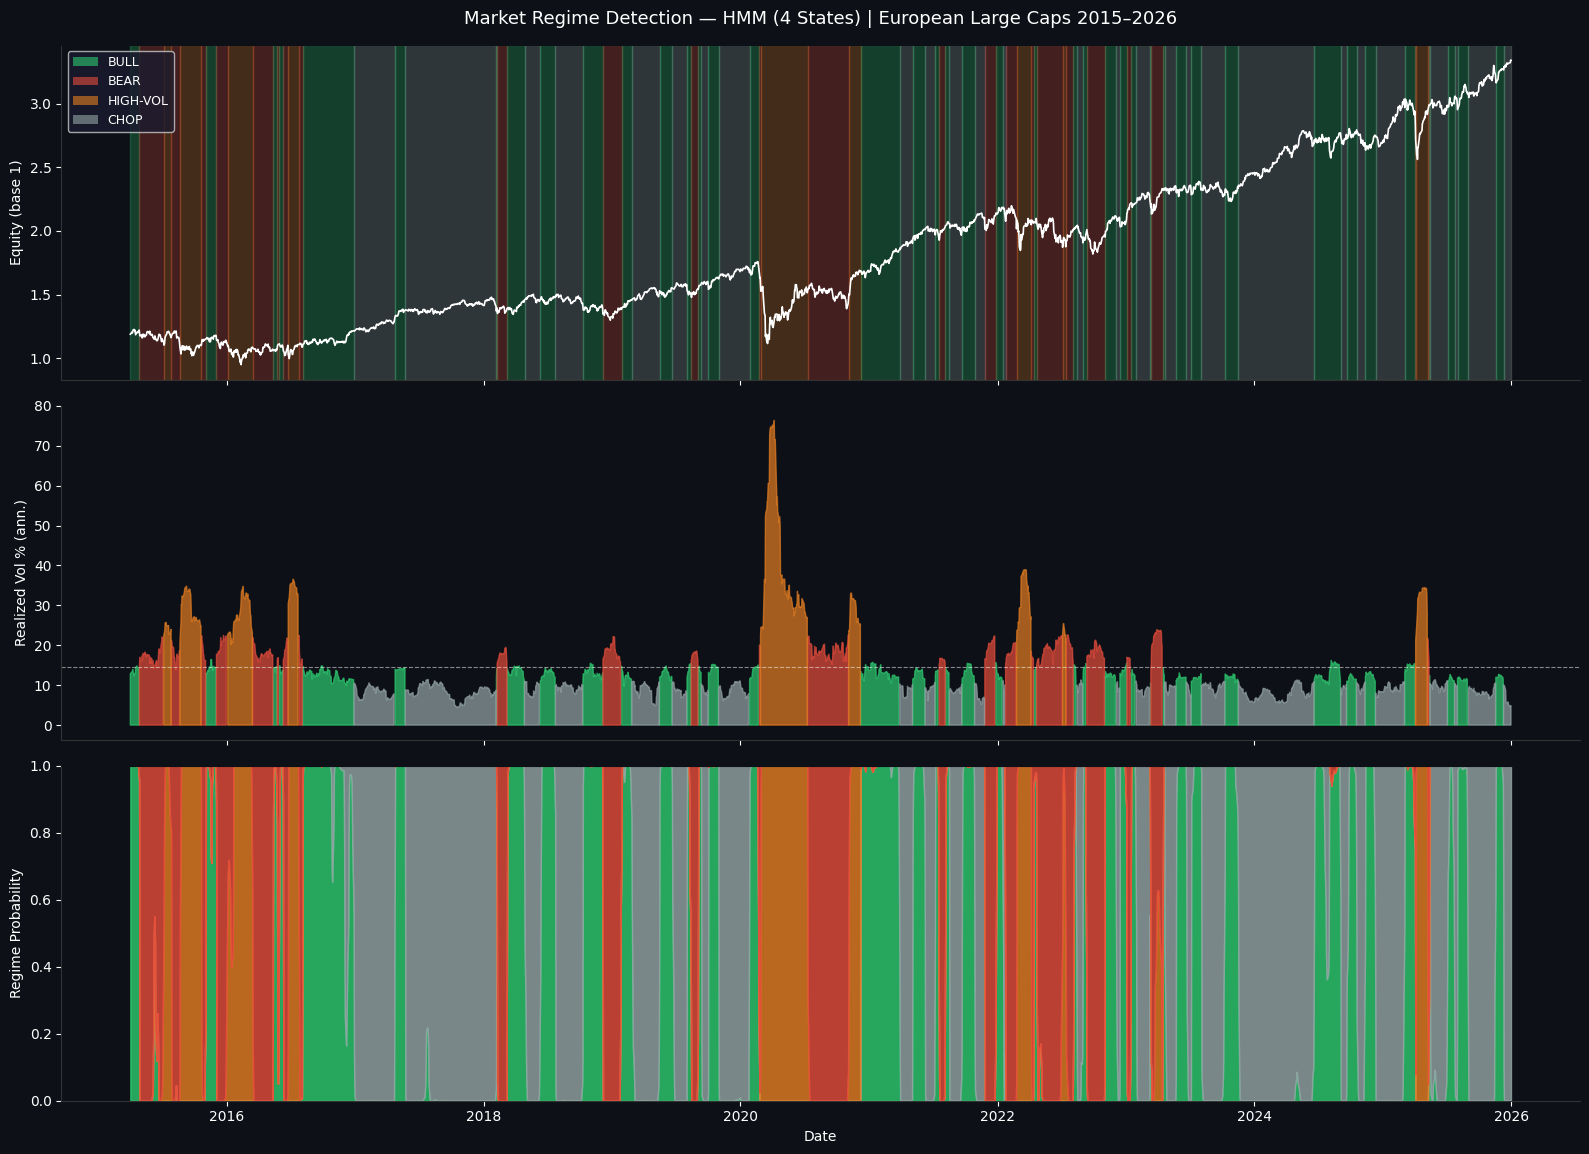

In [7]:
# Cella 3 — Regime visualization con bande colorate
import os
os.makedirs('../results', exist_ok=True)

colors = {
    'BULL':     '#2ecc71',
    'BEAR':     '#e74c3c', 
    'HIGH-VOL': '#e67e22',
    'CHOP':     '#95a5a6'
}

# Equity curve del mercato
equity = (1 + market_returns).cumprod()
equity = equity.reindex(features.index)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#333')
    ax.spines['top'].set_color('#0d1117')
    ax.spines['left'].set_color('#333')
    ax.spines['right'].set_color('#0d1117')

# Panel 1 — Equity curve con bande regime
ax1 = axes[0]
ax1.plot(equity.index, equity.values, color='white', linewidth=1.2, zorder=3)

prev_regime = None
start_idx = features.index[0]

for i, (date, row) in enumerate(features.iterrows()):
    regime = row['hmm_regime']
    if regime != prev_regime:
        if prev_regime is not None:
            ax1.axvspan(start_idx, date, alpha=0.25, 
                       color=colors[prev_regime], zorder=1)
        start_idx = date
        prev_regime = regime

ax1.axvspan(start_idx, features.index[-1], alpha=0.25,
            color=colors[prev_regime], zorder=1)

ax1.set_ylabel('Equity (base 1)', color='white', fontsize=10)
ax1.set_title('Market Regime Detection — HMM (4 States) | European Large Caps 2015–2026',
              color='white', fontsize=13, pad=15)

# Legenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.6, label=r) 
                   for r, c in colors.items()]
ax1.legend(handles=legend_elements, loc='upper left', 
           facecolor='#1a1a2e', labelcolor='white', fontsize=9)

# Panel 2 — Volatilità realizzata colorata per regime
ax2 = axes[1]
for regime, color in colors.items():
    mask = features['hmm_regime'] == regime
    ax2.fill_between(features.index, 0, 
                     features['vol_21'].where(mask) * 100,
                     color=color, alpha=0.7, label=regime)

ax2.set_ylabel('Realized Vol % (ann.)', color='white', fontsize=10)
ax2.axhline(y=features['vol_21'].mean() * 100, color='white', 
            linestyle='--', linewidth=0.8, alpha=0.5)

# Panel 3 — Regime probability heatmap nel tempo
ax3 = axes[2]
posteriors = hmm_model.predict_proba(X_hmm)
posteriors_df = pd.DataFrame(posteriors, index=features.index,
                              columns=['BEAR', 'CHOP', 'HIGH-VOL', 'BULL'])

bottom = np.zeros(len(posteriors_df))
regime_order = ['BULL', 'CHOP', 'HIGH-VOL', 'BEAR']
for regime in regime_order:
    # Map back to correct column
    state_col = [k for k, v in state_names.items() if v == regime][0]
    ax3.fill_between(posteriors_df.index, bottom, 
                     bottom + posteriors[: , state_col],
                     color=colors[regime], alpha=0.8, label=regime)
    bottom += posteriors[:, state_col]

ax3.set_ylabel('Regime Probability', color='white', fontsize=10)
ax3.set_xlabel('Date', color='white', fontsize=10)
ax3.set_ylim(0, 1)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('../results/regime_detection_hmm.png', dpi=150, 
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

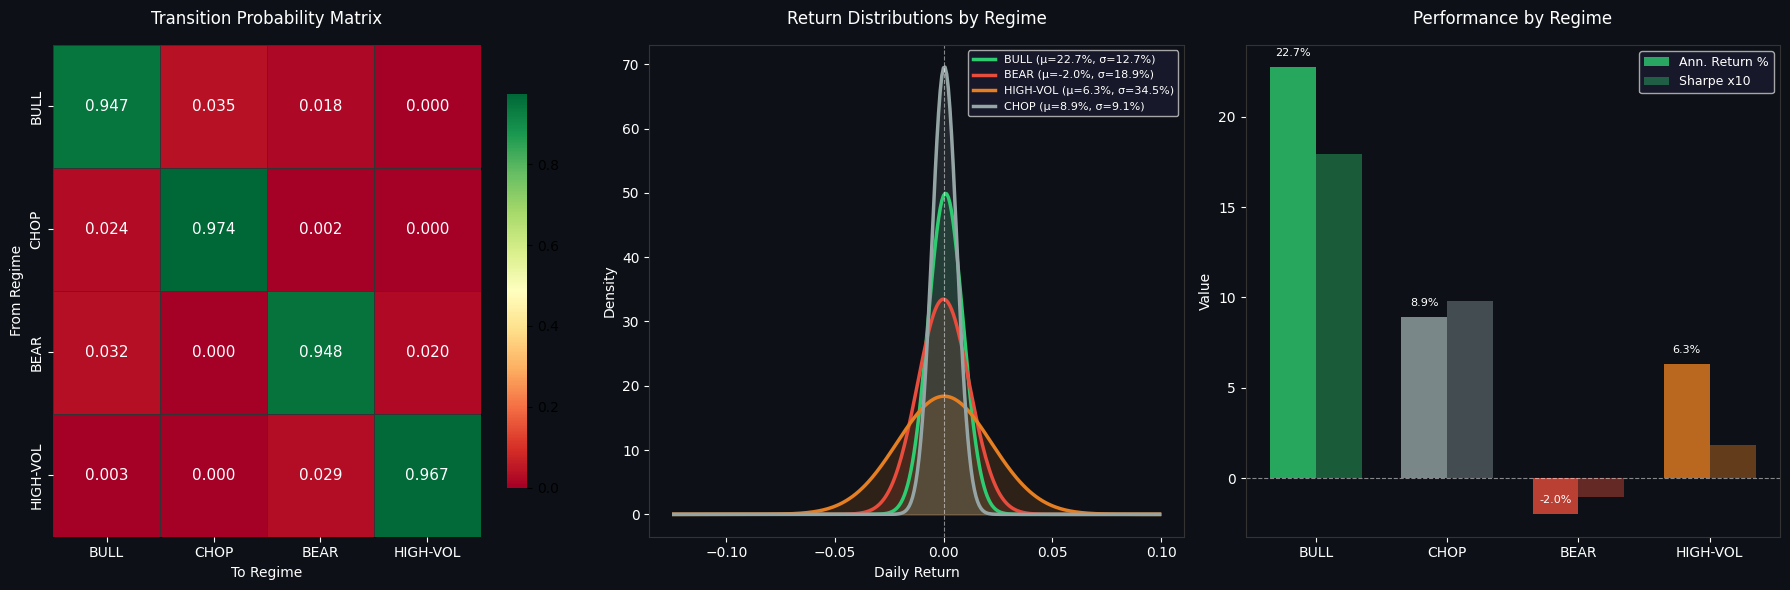

In [8]:
# Cella 4 — Transition matrix heatmap + distribuzioni rendimenti per regime

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#333')

# Panel 1 — Transition Matrix Heatmap
regime_order = ['BULL', 'CHOP', 'BEAR', 'HIGH-VOL']
state_order = [k for r in regime_order for k, v in state_names.items() if v == r]

trans_matrix = pd.DataFrame(
    hmm_model.transmat_[np.ix_(state_order, state_order)],
    index=regime_order,
    columns=regime_order
)

mask = np.eye(4, dtype=bool)
sns.heatmap(trans_matrix, annot=True, fmt='.3f', 
            cmap='RdYlGn', ax=axes[0],
            linewidths=0.5, linecolor='#333',
            annot_kws={'size': 11, 'color': 'white'},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Transition Probability Matrix', color='white', fontsize=12, pad=15)
axes[0].set_xlabel('To Regime', color='white', fontsize=10)
axes[0].set_ylabel('From Regime', color='white', fontsize=10)
axes[0].tick_params(colors='white')
axes[0].xaxis.label.set_color('white')
axes[0].yaxis.label.set_color('white')

# Panel 2 — Distribuzioni rendimenti per regime
from scipy.stats import norm
x_range = np.linspace(features['returns'].min(), features['returns'].max(), 300)

for regime, color in colors.items():
    data = features[features['hmm_regime'] == regime]['returns']
    mu, sigma = data.mean(), data.std()
    axes[1].plot(x_range, norm.pdf(x_range, mu, sigma),
                color=color, linewidth=2.5, label=f'{regime} (μ={mu*252:.1%}, σ={sigma*np.sqrt(252):.1%})')
    axes[1].fill_between(x_range, norm.pdf(x_range, mu, sigma), alpha=0.15, color=color)

axes[1].set_title('Return Distributions by Regime', color='white', fontsize=12, pad=15)
axes[1].set_xlabel('Daily Return', color='white', fontsize=10)
axes[1].set_ylabel('Density', color='white', fontsize=10)
axes[1].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
axes[1].axvline(x=0, color='white', linestyle='--', linewidth=0.8, alpha=0.5)

# Panel 3 — Sharpe e Return per regime (bar chart)
regime_perf = features.groupby('hmm_regime').agg(
    return_annuo=('returns', lambda x: x.mean() * 252 * 100),
    sharpe=('returns', lambda x: (x.mean() * 252) / (x.std() * np.sqrt(252)))
).reindex(regime_order)

x = np.arange(len(regime_order))
width = 0.35

bars1 = axes[2].bar(x - width/2, regime_perf['return_annuo'], width,
                     color=[colors[r] for r in regime_order], alpha=0.8, label='Ann. Return %')
bars2 = axes[2].bar(x + width/2, regime_perf['sharpe'] * 10, width,
                     color=[colors[r] for r in regime_order], alpha=0.4, label='Sharpe x10')

axes[2].set_xticks(x)
axes[2].set_xticklabels(regime_order, color='white')
axes[2].set_title('Performance by Regime', color='white', fontsize=12, pad=15)
axes[2].set_ylabel('Value', color='white', fontsize=10)
axes[2].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
axes[2].axhline(y=0, color='white', linestyle='--', linewidth=0.8, alpha=0.5)

for bar in bars1:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', color='white', fontsize=8)

plt.tight_layout()
plt.savefig('../results/regime_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

PERFORMANCE COMPARISON:

Buy & Hold:        {'Return': '10.85%', 'Vol': '16.78%', 'Sharpe': '0.65', 'Max DD': '-36.52%'}
Regime Filtered:   {'Return': '10.52%', 'Vol': '9.08%', 'Sharpe': '1.16', 'Max DD': '-9.36%'}
Regime Inverse:    {'Return': '10.89%', 'Vol': '12.21%', 'Sharpe': '0.89', 'Max DD': '-15.14%'}


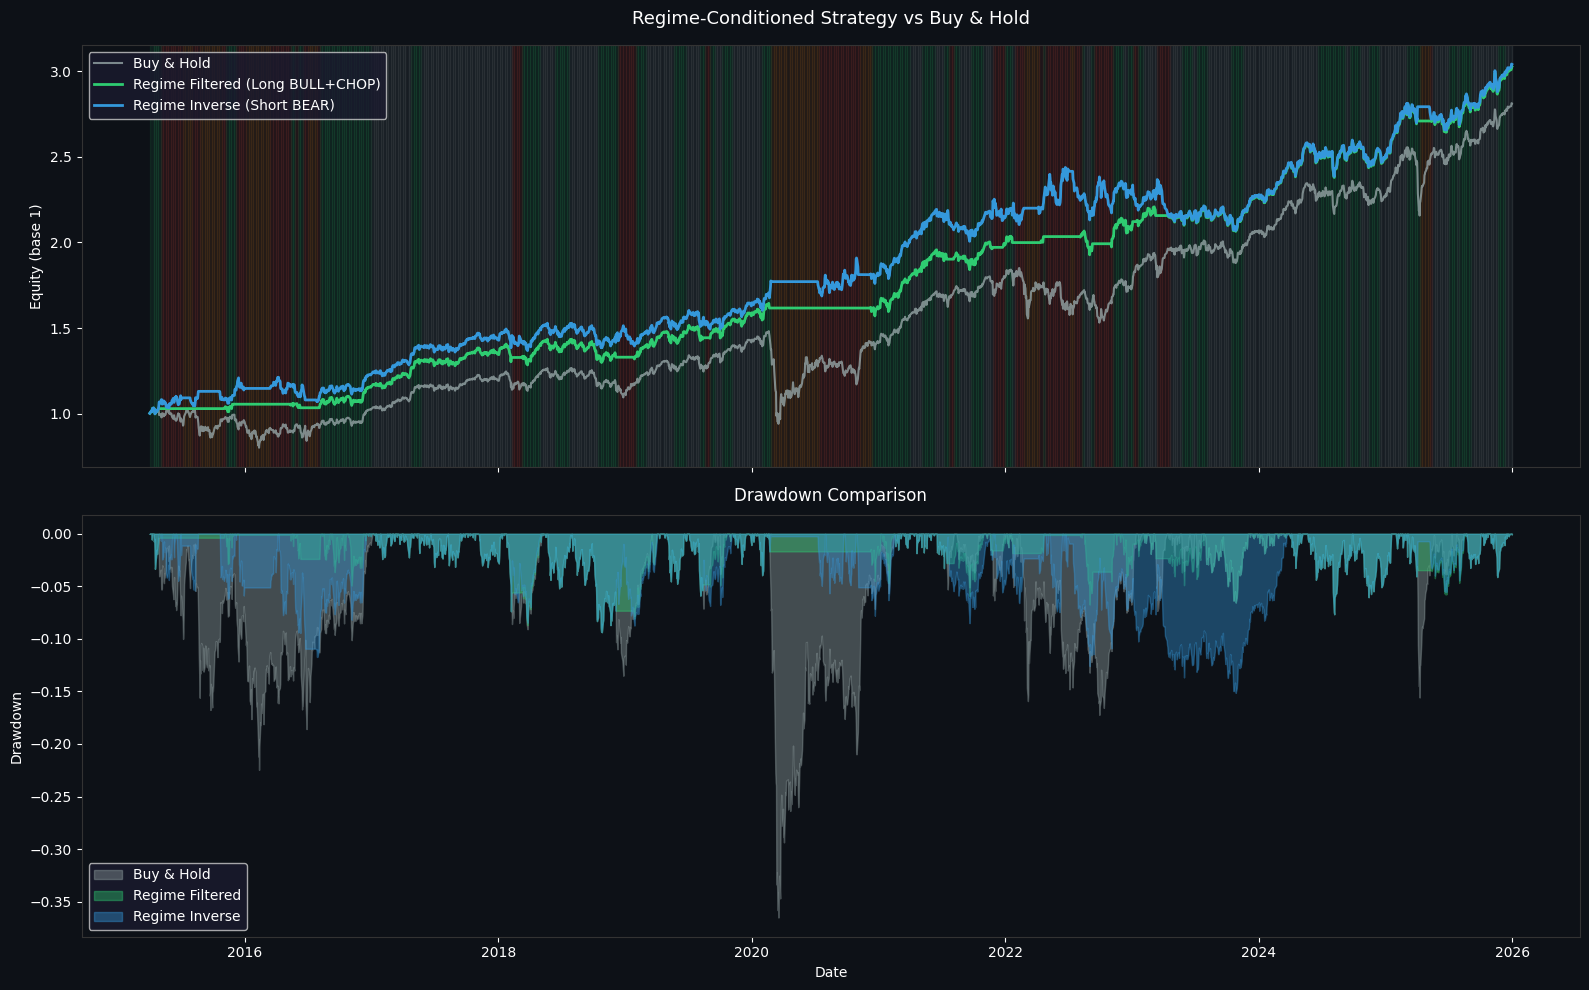

In [9]:
# Cella 5 — Regime-conditioned strategy vs Buy & Hold

# Strategia 1: Buy & Hold
bh_returns = market_returns.reindex(features.index)
bh_equity = (1 + bh_returns).cumprod()

# Strategia 2: Regime-filtered — investito solo in BULL e CHOP
regime_filter = features['hmm_regime'].isin(['BULL', 'CHOP'])
filtered_returns = bh_returns.where(regime_filter, 0)
filtered_equity = (1 + filtered_returns).cumprod()

# Strategia 3: Inversa — short in BEAR, flat in HIGH-VOL
inverse_returns = bh_returns.copy()
inverse_returns[features['hmm_regime'] == 'BEAR'] *= -1
inverse_returns[features['hmm_regime'] == 'HIGH-VOL'] = 0
inverse_equity = (1 + inverse_returns).cumprod()

# Metriche
def metrics(returns):
    ann_return = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol
    max_dd = ((1 + returns).cumprod() / (1 + returns).cumprod().cummax() - 1).min()
    return {'Return': f'{ann_return:.2%}', 'Vol': f'{ann_vol:.2%}', 
            'Sharpe': f'{sharpe:.2f}', 'Max DD': f'{max_dd:.2%}'}

print("PERFORMANCE COMPARISON:")
print(f"\nBuy & Hold:        {metrics(bh_returns)}")
print(f"Regime Filtered:   {metrics(filtered_returns)}")
print(f"Regime Inverse:    {metrics(inverse_returns)}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#333')

# Equity curves
axes[0].plot(bh_equity.index, bh_equity.values, 
             color='#95a5a6', linewidth=1.5, label='Buy & Hold', alpha=0.8)
axes[0].plot(filtered_equity.index, filtered_equity.values,
             color='#2ecc71', linewidth=2, label='Regime Filtered (Long BULL+CHOP)')
axes[0].plot(inverse_equity.index, inverse_equity.values,
             color='#3498db', linewidth=2, label='Regime Inverse (Short BEAR)')

# Bande regime in background
for i, (date, row) in enumerate(features.iterrows()):
    if i % 5 == 0:
        axes[0].axvspan(date, features.index[min(i+5, len(features)-1)],
                       alpha=0.08, color=colors[row['hmm_regime']])

axes[0].set_title('Regime-Conditioned Strategy vs Buy & Hold', 
                  color='white', fontsize=13, pad=15)
axes[0].set_ylabel('Equity (base 1)', color='white', fontsize=10)
axes[0].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=10)

# Drawdown
for equity_curve, color, label in [
    (bh_equity, '#95a5a6', 'Buy & Hold'),
    (filtered_equity, '#2ecc71', 'Regime Filtered'),
    (inverse_equity, '#3498db', 'Regime Inverse')
]:
    dd = equity_curve / equity_curve.cummax() - 1
    axes[1].fill_between(dd.index, dd.values, 0, alpha=0.4, color=color, label=label)

axes[1].set_title('Drawdown Comparison', color='white', fontsize=12, pad=10)
axes[1].set_ylabel('Drawdown', color='white', fontsize=10)
axes[1].set_xlabel('Date', color='white', fontsize=10)
axes[1].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('../results/regime_strategy.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


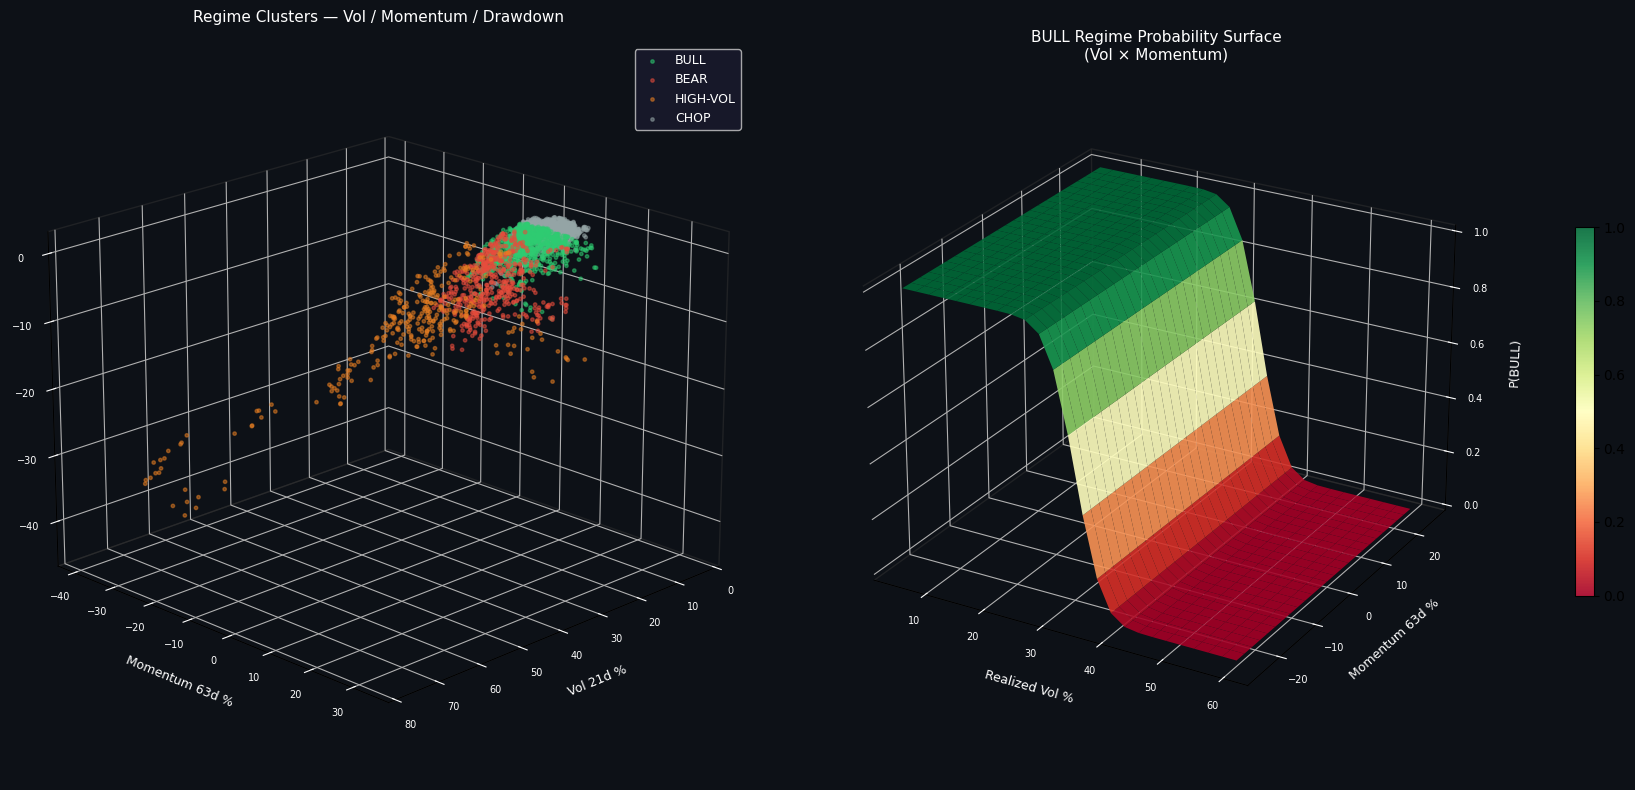

In [11]:
# Cella 6 — 3D grafici corretti

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor('#0d1117')

# Panel 1 — 3D scatter VOL vs MOMENTUM vs DRAWDOWN colorato per regime
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('#0d1117')

for regime, color in colors.items():
    mask = features['hmm_regime'] == regime
    ax1.scatter(
        features.loc[mask, 'vol_21'] * 100,
        features.loc[mask, 'momentum_63'] * 100,
        features.loc[mask, 'drawdown'] * 100,
        c=color, alpha=0.5, s=6, label=regime
    )

ax1.set_xlabel('Vol 21d %', color='white', fontsize=9, labelpad=8)
ax1.set_ylabel('Momentum 63d %', color='white', fontsize=9, labelpad=8)
ax1.set_zlabel('Drawdown %', color='white', fontsize=9, labelpad=8)
ax1.set_title('Regime Clusters — Vol / Momentum / Drawdown', 
              color='white', fontsize=11, pad=15)
ax1.tick_params(colors='white', labelsize=7)
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False
ax1.xaxis.pane.set_edgecolor('#333')
ax1.yaxis.pane.set_edgecolor('#333')
ax1.zaxis.pane.set_edgecolor('#333')
ax1.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax1.view_init(elev=20, azim=45)

# Panel 2 — BULL probability surface corretta
# Varia VOL e MOMENTUM, usa la distribuzione reale dei returns
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_facecolor('#0d1117')

vol_bins = np.linspace(0.05, 0.60, 25)
mom_bins = np.linspace(-0.25, 0.25, 25)
V, M = np.meshgrid(vol_bins, mom_bins)
bull_state = [k for k, v in state_names.items() if v == 'BULL'][0]

Z = np.zeros_like(V)
for i in range(len(mom_bins)):
    for j in range(len(vol_bins)):
        # Usa return medio condizionato alla volatilità
        r_proxy = mom_bins[i] / 63
        x_point = np.array([[r_proxy, vol_bins[j]]])
        try:
            log_prob = hmm_model.score(x_point)
            probs = hmm_model.predict_proba(x_point)
            Z[i, j] = probs[0, bull_state]
        except:
            Z[i, j] = np.nan

# Smoothing leggero
from scipy.ndimage import gaussian_filter
Z_smooth = gaussian_filter(Z, sigma=1.5)

surf = ax2.plot_surface(V * 100, M * 100, Z_smooth,
                         cmap='RdYlGn', alpha=0.9,
                         linewidth=0, antialiased=True)

ax2.set_xlabel('Realized Vol %', color='white', fontsize=9, labelpad=8)
ax2.set_ylabel('Momentum 63d %', color='white', fontsize=9, labelpad=8)
ax2.set_zlabel('P(BULL)', color='white', fontsize=9, labelpad=8)
ax2.set_title('BULL Regime Probability Surface\n(Vol × Momentum)', 
              color='white', fontsize=11, pad=15)
ax2.tick_params(colors='white', labelsize=7)
ax2.xaxis.pane.fill = False
ax2.yaxis.pane.fill = False
ax2.zaxis.pane.fill = False
ax2.xaxis.pane.set_edgecolor('#333')
ax2.yaxis.pane.set_edgecolor('#333')
ax2.zaxis.pane.set_edgecolor('#333')
ax2.view_init(elev=25, azim=-60)
fig.colorbar(surf, ax=ax2, shrink=0.5, pad=0.1)

plt.tight_layout()
plt.savefig('../results/regime_3d.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

CONFRONTO QUALITÀ CLUSTERING:
Metrica                               HMM    K-means
----------------------------------------------------
Silhouette Score                   0.0756     0.3871
Calinski-Harabasz Score             550.3     1151.4

PERSISTENZA MEDIA DEI REGIMI (giorni):
Regime              HMM    K-means
----------------------------------
BULL               20.8        1.7
BEAR               21.5        2.1
CHOP               40.1       14.8
HIGH-VOL           34.3       11.0


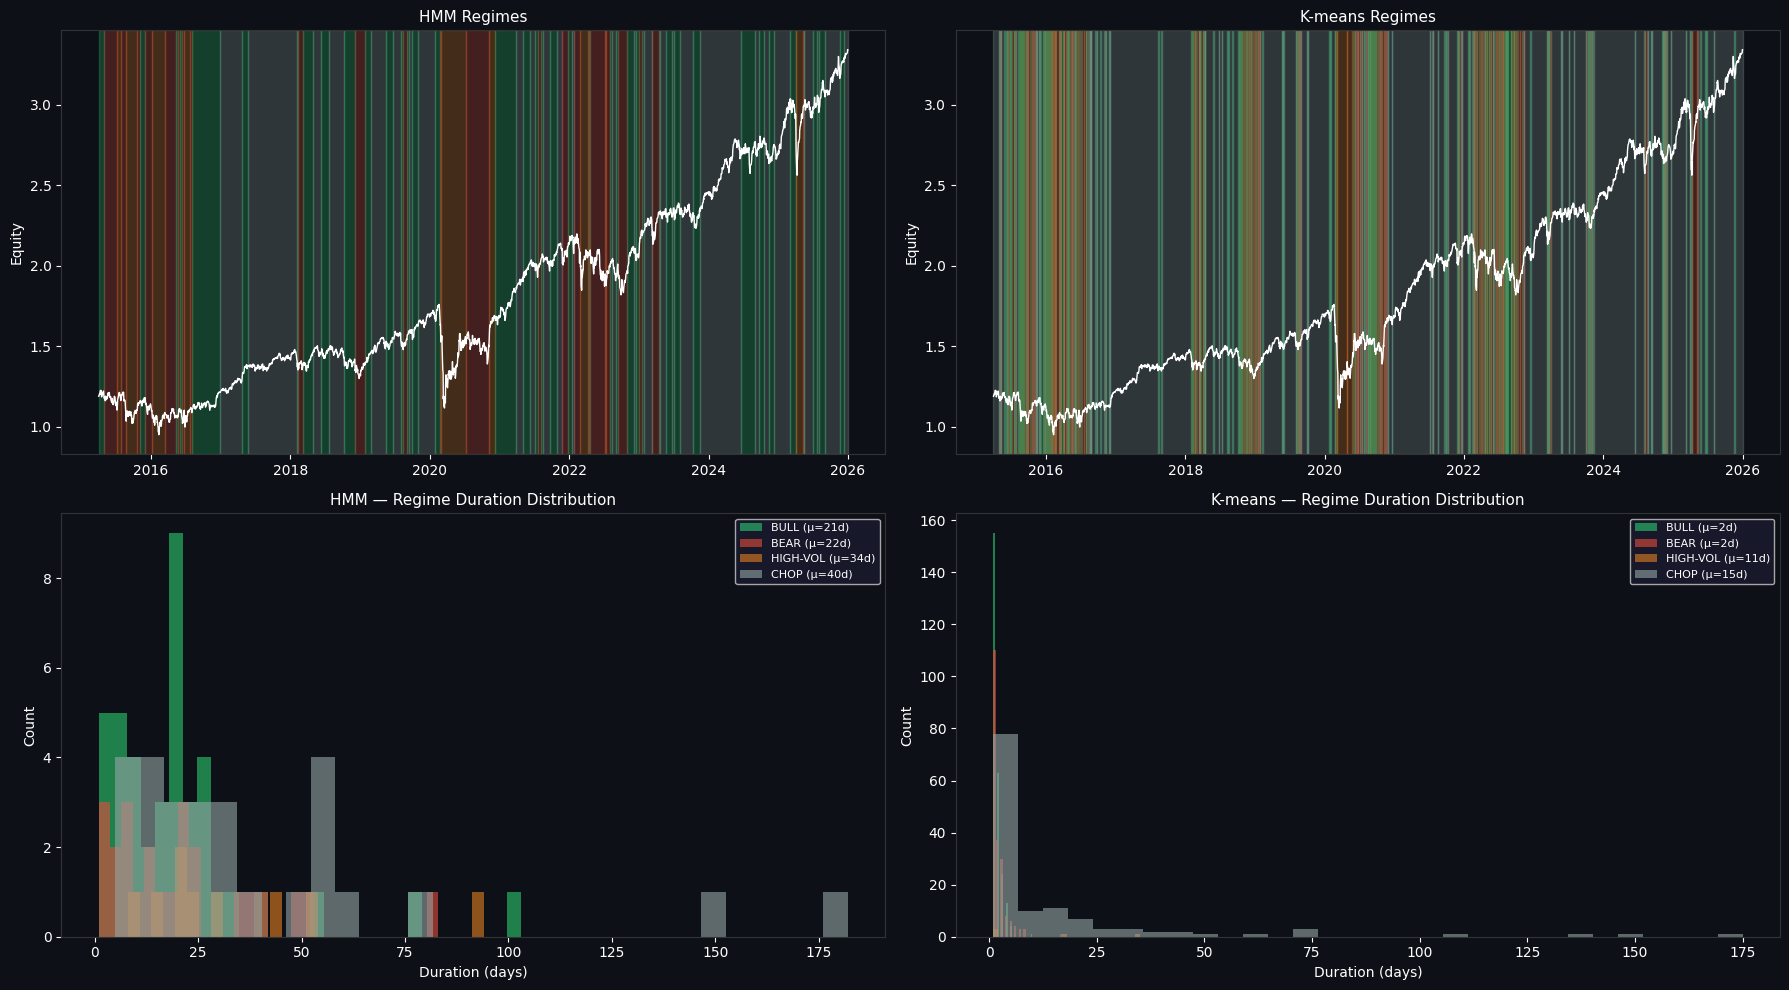

In [12]:
# Cella 7 — HMM vs K-means: confronto metodologico

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# K-means con 4 cluster sulle stesse feature
X_scaled = StandardScaler().fit_transform(
    features[['returns', 'vol_21', 'momentum_63', 'drawdown']]
)
kmeans = KMeans(n_clusters=4, n_init=50, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Mappa K-means per volatilità media
km_stats = pd.DataFrame({
    'label': kmeans_labels,
    'vol': features['vol_21'].values,
    'ret': features['returns'].values
})
vol_order = km_stats.groupby('label')['vol'].mean().sort_values()
km_name_map = {
    vol_order.index[0]: 'CHOP',
    vol_order.index[1]: 'BULL',
    vol_order.index[2]: 'BEAR',
    vol_order.index[3]: 'HIGH-VOL'
}
kmeans_regime = pd.Series(kmeans_labels, 
                           index=features.index).map(km_name_map)

# Metriche di qualità clustering
hmm_labels_num = features['hmm_state'].values
sil_hmm = silhouette_score(X_scaled, hmm_labels_num)
sil_km  = silhouette_score(X_scaled, kmeans_labels)
ch_hmm  = calinski_harabasz_score(X_scaled, hmm_labels_num)
ch_km   = calinski_harabasz_score(X_scaled, kmeans_labels)

print("CONFRONTO QUALITÀ CLUSTERING:")
print(f"{'Metrica':<30} {'HMM':>10} {'K-means':>10}")
print("-" * 52)
print(f"{'Silhouette Score':<30} {sil_hmm:>10.4f} {sil_km:>10.4f}")
print(f"{'Calinski-Harabasz Score':<30} {ch_hmm:>10.1f} {ch_km:>10.1f}")

# Regime persistence: HMM vs K-means
def regime_persistence(regime_series):
    runs = []
    current = regime_series.iloc[0]
    count = 1
    for val in regime_series.iloc[1:]:
        if val == current:
            count += 1
        else:
            runs.append((current, count))
            current = val
            count = 1
    runs.append((current, count))
    return pd.DataFrame(runs, columns=['regime', 'duration'])

hmm_runs = regime_persistence(features['hmm_regime'])
km_runs  = regime_persistence(kmeans_regime)

print("\nPERSISTENZA MEDIA DEI REGIMI (giorni):")
print(f"{'Regime':<12} {'HMM':>10} {'K-means':>10}")
print("-" * 34)
for regime in ['BULL', 'BEAR', 'CHOP', 'HIGH-VOL']:
    hmm_dur = hmm_runs[hmm_runs['regime'] == regime]['duration'].mean()
    km_dur  = km_runs[km_runs['regime'] == regime]['duration'].mean()
    print(f"{regime:<12} {hmm_dur:>10.1f} {km_dur:>10.1f}")

# Visualizzazione affiancata
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes.flat:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#333')

equity = (1 + market_returns).cumprod().reindex(features.index)

# HMM equity con bande
ax = axes[0, 0]
ax.plot(equity.index, equity.values, color='white', linewidth=1, zorder=3)
prev, start = None, features.index[0]
for date, row in features.iterrows():
    r = row['hmm_regime']
    if r != prev:
        if prev:
            ax.axvspan(start, date, alpha=0.25, color=colors[prev])
        start, prev = date, r
ax.axvspan(start, features.index[-1], alpha=0.25, color=colors[prev])
ax.set_title('HMM Regimes', color='white', fontsize=11)
ax.set_ylabel('Equity', color='white')

# K-means equity con bande
ax = axes[0, 1]
ax.plot(equity.index, equity.values, color='white', linewidth=1, zorder=3)
prev, start = None, features.index[0]
for date, regime in kmeans_regime.items():
    if regime != prev:
        if prev:
            ax.axvspan(start, date, alpha=0.25, color=colors.get(prev, '#999'))
        start, prev = date, regime
ax.axvspan(start, kmeans_regime.index[-1], alpha=0.25, color=colors.get(prev, '#999'))
ax.set_title('K-means Regimes', color='white', fontsize=11)
ax.set_ylabel('Equity', color='white')

# Distribuzione durata HMM
ax = axes[1, 0]
for regime, color in colors.items():
    dur = hmm_runs[hmm_runs['regime'] == regime]['duration']
    ax.hist(dur, bins=30, color=color, alpha=0.6, label=f'{regime} (μ={dur.mean():.0f}d)')
ax.set_title('HMM — Regime Duration Distribution', color='white', fontsize=11)
ax.set_xlabel('Duration (days)', color='white')
ax.set_ylabel('Count', color='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)

# Distribuzione durata K-means
ax = axes[1, 1]
for regime, color in colors.items():
    dur = km_runs[km_runs['regime'] == regime]['duration']
    if len(dur) > 0:
        ax.hist(dur, bins=30, color=color, alpha=0.6, label=f'{regime} (μ={dur.mean():.0f}d)')
ax.set_title('K-means — Regime Duration Distribution', color='white', fontsize=11)
ax.set_xlabel('Duration (days)', color='white')
ax.set_ylabel('Count', color='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('../results/hmm_vs_kmeans.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

Walk-Forward Training Schedule:
Window   Train Start    Train End      Test Start     Test End       Days OOS
--------------------------------------------------------------------------------
1        2015-04-02     2017-03-15     2017-03-16     2017-09-11     126
2        2015-04-02     2017-09-11     2017-09-12     2018-03-09     126
3        2015-04-02     2018-03-09     2018-03-12     2018-09-05     126


Model is not converging.  Current: 4906.673205966658 is not greater than 4906.834460140695. Delta is -0.16125417403691245


4        2015-04-02     2018-09-05     2018-09-06     2019-03-05     126
5        2015-04-02     2019-03-05     2019-03-06     2019-08-30     126
6        2015-04-02     2019-08-30     2019-09-02     2020-02-26     126
7        2015-04-02     2020-02-26     2020-02-27     2020-08-24     126
8        2015-04-02     2020-08-24     2020-08-25     2021-02-18     126
9        2015-04-02     2021-02-18     2021-02-19     2021-08-17     126


Model is not converging.  Current: 8976.213082976488 is not greater than 8976.365726415634. Delta is -0.1526434391453222


10       2015-04-02     2021-08-17     2021-08-18     2022-02-09     126
11       2015-04-02     2022-02-09     2022-02-10     2022-08-08     126
12       2015-04-02     2022-08-08     2022-08-09     2023-02-01     126


Model is not converging.  Current: 11608.567155252047 is not greater than 11608.596563846788. Delta is -0.029408594740743865


13       2015-04-02     2023-02-01     2023-02-02     2023-07-31     126
14       2015-04-02     2023-07-31     2023-08-01     2024-01-26     126
15       2015-04-02     2024-01-26     2024-01-29     2024-07-24     126
16       2015-04-02     2024-07-24     2024-07-25     2025-01-21     126
17       2015-04-02     2025-01-21     2025-01-22     2025-07-18     126
18       2015-04-02     2025-07-18     2025-07-21     2025-12-31     116

Totale giorni out-of-sample: 2258
Periodo OOS: 2017-03-16 — 2025-12-31

PERFORMANCE OUT-OF-SAMPLE (Walk-Forward):
Strategia                Return        Vol     Sharpe     Max DD
--------------------------------------------------------------
Buy & Hold               12.06%     16.13%       0.75    -36.52%
Regime Filtered          10.04%     10.65%       0.94    -15.44%


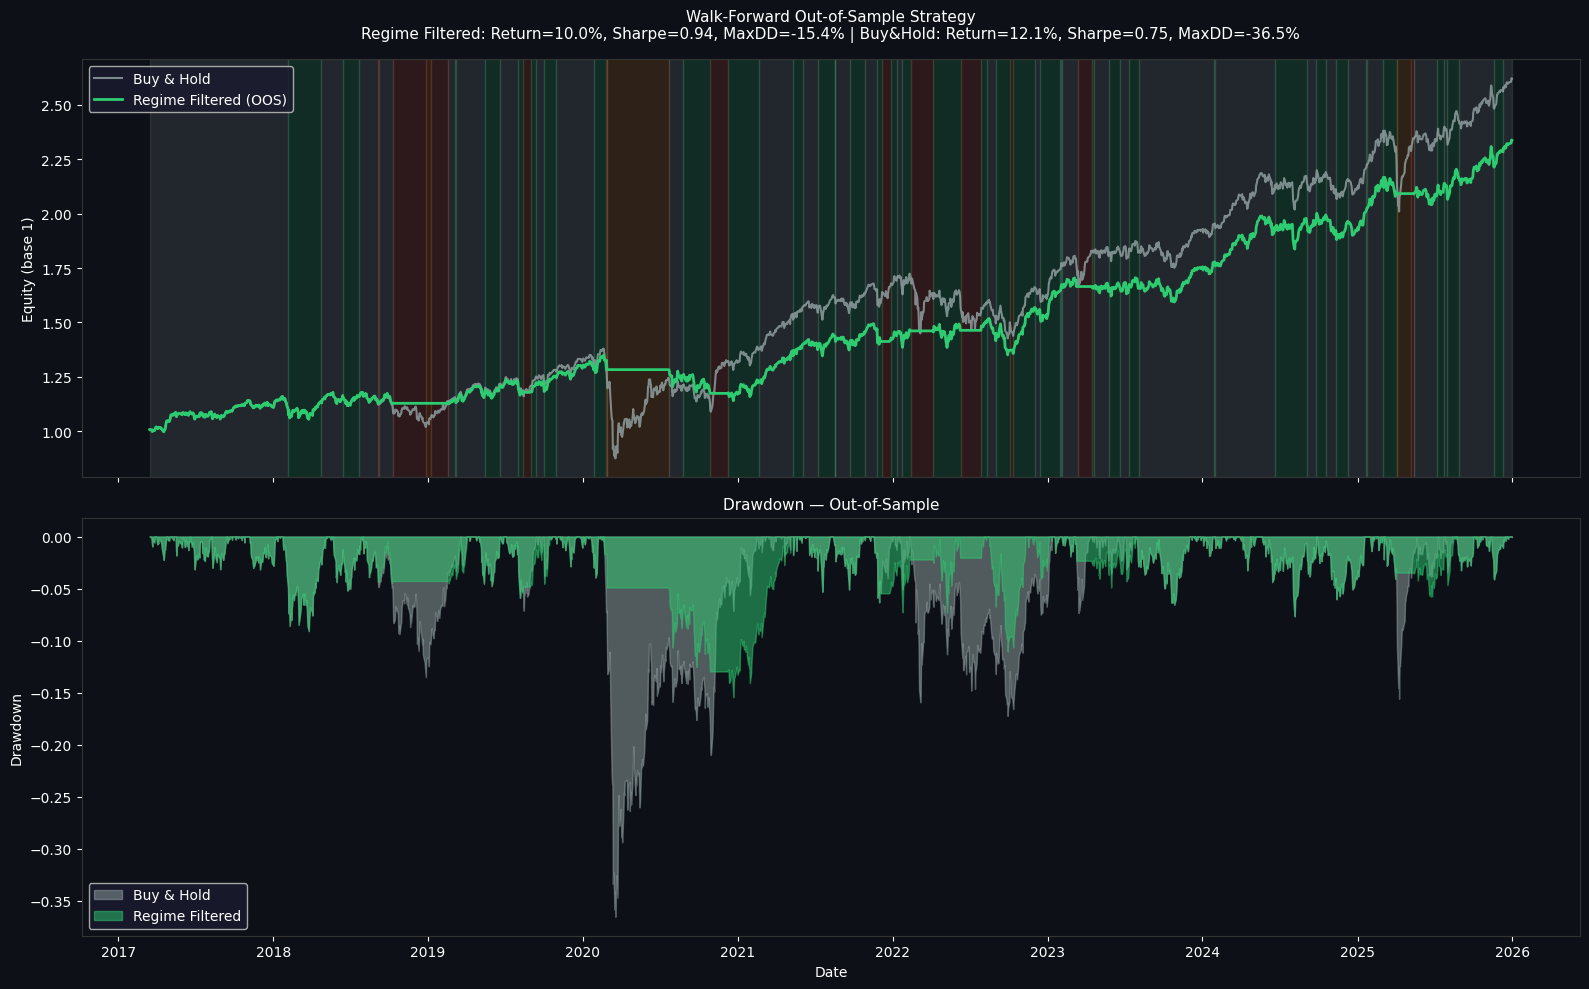

In [15]:
# Cella 8 — Walk-Forward Validation
# Il modello viene riallenato ogni 6 mesi su dati passati
# e applicato out-of-sample sul semestre successivo

from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

TRAIN_WINDOW = 504   # 2 anni di training iniziale
RETRAIN_FREQ = 126   # riallenamento ogni 6 mesi
N_STATES = 4

X_wf = features[['returns', 'vol_21']].values
dates = features.index
n = len(X_wf)

oos_regimes = pd.Series(index=dates, dtype=str)
oos_regimes[:] = 'UNKNOWN'

print("Walk-Forward Training Schedule:")
print(f"{'Window':<8} {'Train Start':<14} {'Train End':<14} {'Test Start':<14} {'Test End':<14} {'Days OOS'}")
print("-" * 80)

window_count = 0
for start in range(TRAIN_WINDOW, n, RETRAIN_FREQ):
    train_end = start
    test_end = min(start + RETRAIN_FREQ, n)

    X_train = X_wf[:train_end]
    X_test = X_wf[train_end:test_end]

    # Riallenamento HMM su dati passati
    model_wf = GaussianHMM(
        n_components=N_STATES,
        covariance_type='diag',
        n_iter=500,
        random_state=42
    )
    model_wf.fit(X_train)

    # Predizione out-of-sample
    test_states = model_wf.predict(X_test)

    # Mappa stati per volatilità media (euristica stabile)
    state_vols = {i: X_train[model_wf.predict(X_train) == i, 1].mean() 
                  for i in range(N_STATES)}
    vol_sorted = sorted(state_vols.items(), key=lambda x: x[1])
    state_map = {
        vol_sorted[0][0]: 'CHOP',
        vol_sorted[1][0]: 'BULL',
        vol_sorted[2][0]: 'BEAR',
        vol_sorted[3][0]: 'HIGH-VOL'
    }

    mapped = [state_map[s] for s in test_states]
    oos_regimes.iloc[train_end:test_end] = mapped

    window_count += 1
    print(f"{window_count:<8} {str(dates[0].date()):<14} {str(dates[train_end-1].date()):<14} "
          f"{str(dates[train_end].date()):<14} {str(dates[test_end-1].date()):<14} {test_end - train_end}")

print(f"\nTotale giorni out-of-sample: {(oos_regimes != 'UNKNOWN').sum()}")
print(f"Periodo OOS: {oos_regimes[oos_regimes != 'UNKNOWN'].index[0].date()} "
      f"— {oos_regimes[oos_regimes != 'UNKNOWN'].index[-1].date()}")

# Strategia regime-filtered OOS
oos_mask = oos_regimes != 'UNKNOWN'
common_idx = market_returns.index.intersection(oos_regimes[oos_mask].index)
oos_returns = market_returns.loc[common_idx]
oos_regimes_clean = oos_regimes.loc[common_idx]

bh_oos = oos_returns
filtered_oos = oos_returns.where(oos_regimes_clean.isin(['BULL', 'CHOP']), 0)

def metrics(returns):
    ann_ret = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    max_dd = ((1 + returns).cumprod() / (1 + returns).cumprod().cummax() - 1).min()
    return ann_ret, ann_vol, sharpe, max_dd

bh_r, bh_v, bh_s, bh_dd = metrics(bh_oos)
fl_r, fl_v, fl_s, fl_dd = metrics(filtered_oos)

print("\nPERFORMANCE OUT-OF-SAMPLE (Walk-Forward):")
print(f"{'Strategia':<20} {'Return':>10} {'Vol':>10} {'Sharpe':>10} {'Max DD':>10}")
print("-" * 62)
print(f"{'Buy & Hold':<20} {bh_r:>10.2%} {bh_v:>10.2%} {bh_s:>10.2f} {bh_dd:>10.2%}")
print(f"{'Regime Filtered':<20} {fl_r:>10.2%} {fl_v:>10.2%} {fl_s:>10.2f} {fl_dd:>10.2%}")

# Plot OOS
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#333')

bh_equity_oos = (1 + bh_oos).cumprod()
fl_equity_oos = (1 + filtered_oos).cumprod()

axes[0].plot(bh_equity_oos.index, bh_equity_oos.values,
             color='#95a5a6', linewidth=1.5, label='Buy & Hold', alpha=0.8)
axes[0].plot(fl_equity_oos.index, fl_equity_oos.values,
             color='#2ecc71', linewidth=2, label='Regime Filtered (OOS)')

# Bande regime OOS
prev, start_d = None, oos_regimes_clean.index[0]
for date, regime in oos_regimes_clean.items():
    if regime != prev:
        if prev and prev in colors:
            axes[0].axvspan(start_d, date, alpha=0.15, color=colors[prev])
        start_d, prev = date, regime
if prev in colors:
    axes[0].axvspan(start_d, oos_regimes_clean.index[-1], alpha=0.15, color=colors[prev])

axes[0].set_title(f'Walk-Forward Out-of-Sample Strategy\n'
                  f'Regime Filtered: Return={fl_r:.1%}, Sharpe={fl_s:.2f}, MaxDD={fl_dd:.1%} | '
                  f'Buy&Hold: Return={bh_r:.1%}, Sharpe={bh_s:.2f}, MaxDD={bh_dd:.1%}',
                  color='white', fontsize=11, pad=15)
axes[0].set_ylabel('Equity (base 1)', color='white')
axes[0].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=10)

# Drawdown OOS
for eq, color, label in [
    (bh_equity_oos, '#95a5a6', 'Buy & Hold'),
    (fl_equity_oos, '#2ecc71', 'Regime Filtered')
]:
    dd = eq / eq.cummax() - 1
    axes[1].fill_between(dd.index, dd.values, 0, alpha=0.5, color=color, label=label)

axes[1].set_title('Drawdown — Out-of-Sample', color='white', fontsize=11)
axes[1].set_ylabel('Drawdown', color='white')
axes[1].set_xlabel('Date', color='white')
axes[1].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('../results/walkforward_oos.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

Universo globale: 161 titoli x 2747 giorni
Classificando regimi per ogni titolo...
Matrice regime: 130 titoli x 570 settimane


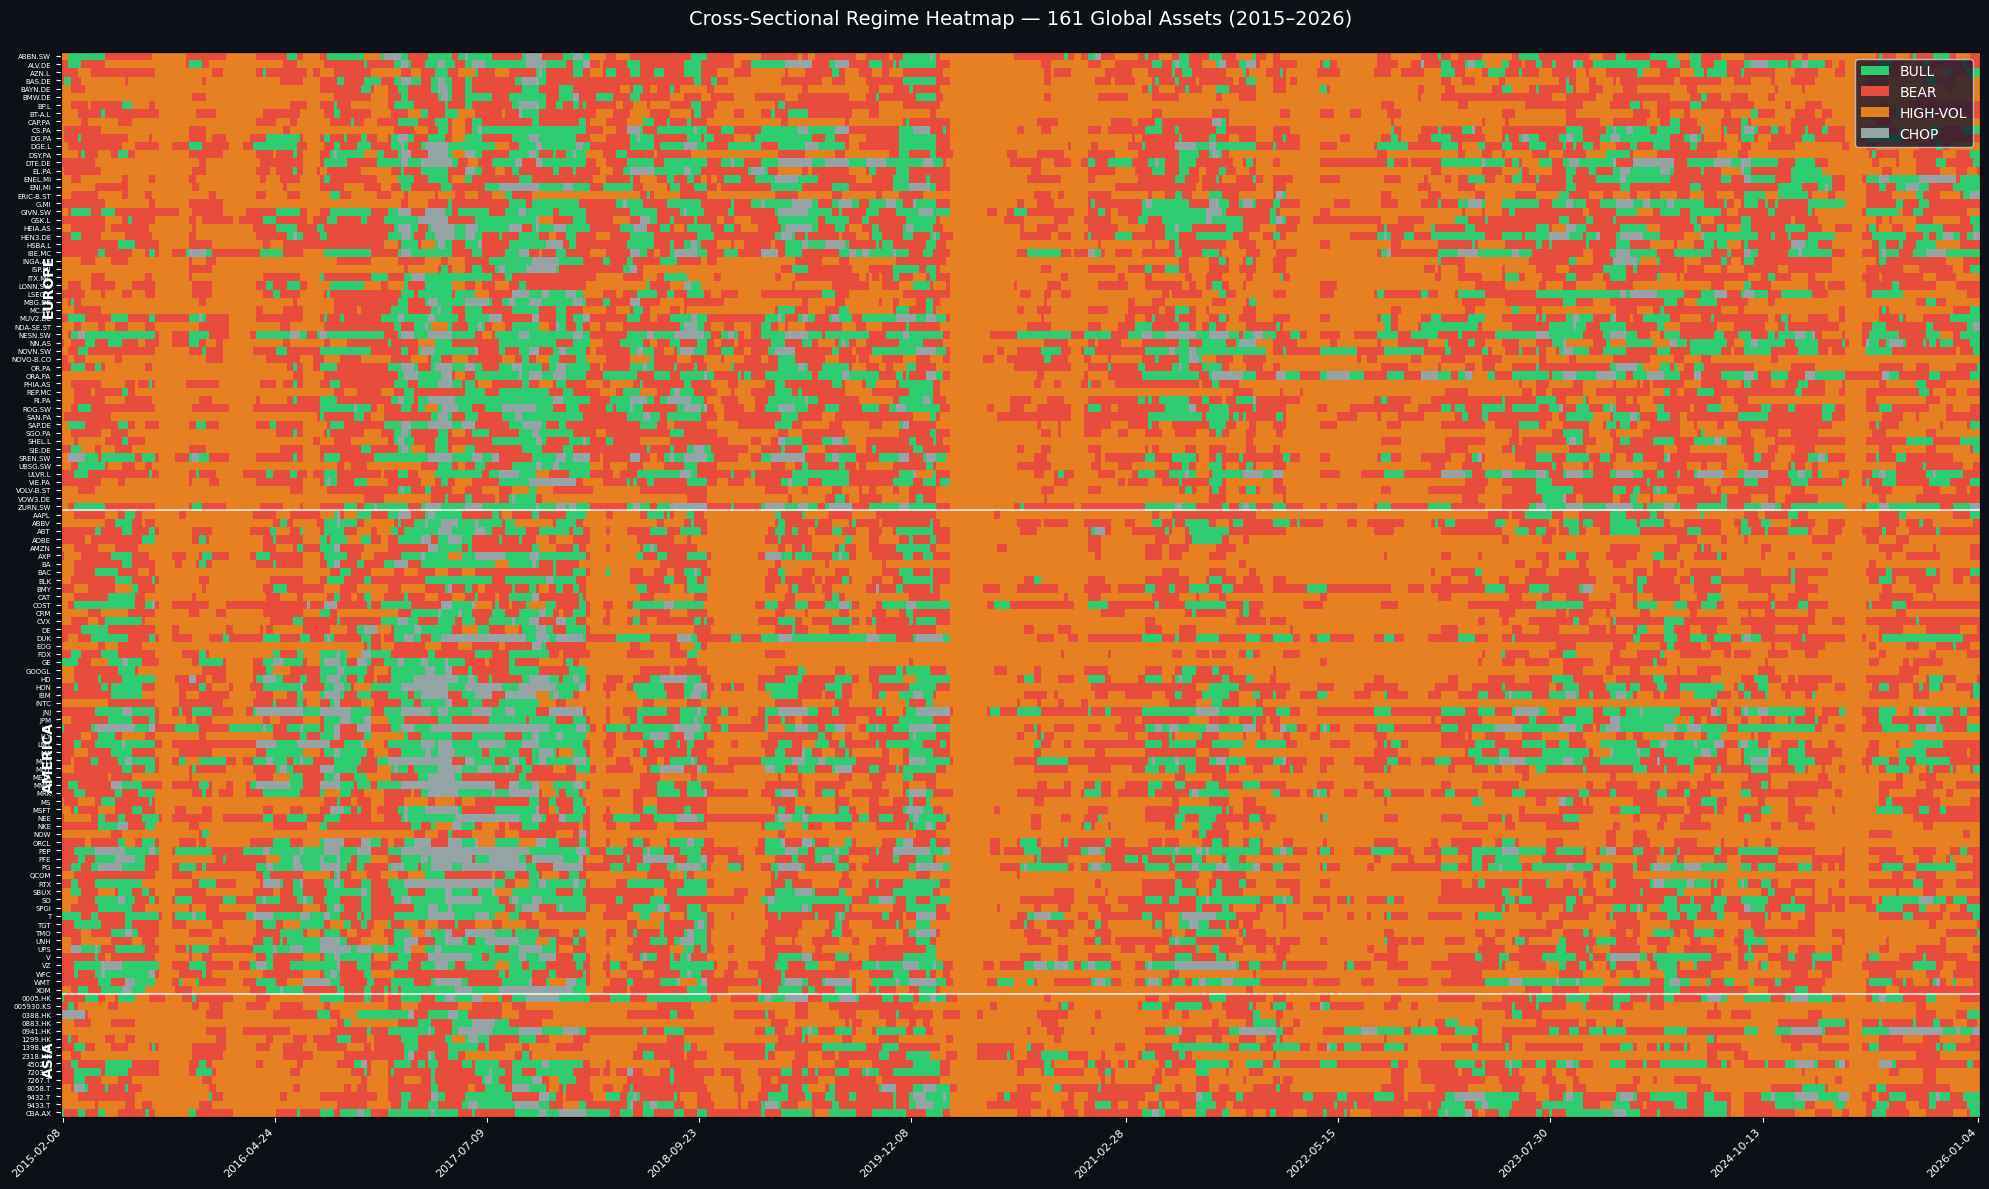

In [17]:
# Cella 9 — Regime heatmap cross-sectionale globale

# Carica tutti e tre gli universi
returns_us = pd.read_csv(
    r'C:\Users\ffran\monte-carlo-sim\data\raw\returns_america.csv',
    index_col=0, parse_dates=True
)
returns_as = pd.read_csv(
    r'C:\Users\ffran\monte-carlo-sim\data\raw\returns_asia.csv',
    index_col=0, parse_dates=True
)

# Allinea tutti e tre
all_returns = returns_eu.join(returns_us, how='inner').join(returns_as, how='inner')
all_returns = all_returns.dropna()
print(f"Universo globale: {all_returns.shape[1]} titoli x {len(all_returns)} giorni")

# Per ogni titolo stima il regime con HMM pre-allenato
# Usa rolling vol + momentum come feature
def get_ticker_regime(ret_series, model):
    vol = ret_series.rolling(21).std() * np.sqrt(252)
    df = pd.DataFrame({'returns': ret_series, 'vol': vol}).dropna()
    if len(df) < 50:
        return pd.Series(dtype=str)
    X = df.values
    states = model.predict(X)
    state_vols = {i: X[states == i, 1].mean() for i in range(4)
                  if (states == i).sum() > 0}
    if len(state_vols) < 4:
        return pd.Series(dtype=str)
    vol_sorted = sorted(state_vols.items(), key=lambda x: x[1])
    smap = {
        vol_sorted[0][0]: 0,
        vol_sorted[1][0]: 1,
        vol_sorted[2][0]: 2,
        vol_sorted[3][0]: 3
    }
    # Usa df.index invece di ret_series.index[21:]
    mapped = pd.Series([smap[s] for s in states], index=df.index)
    return mapped

# Applica a tutti i titoli — campiona ogni settimana per velocità
weekly_idx = all_returns.resample('W').last().index
regime_matrix = pd.DataFrame(index=weekly_idx, dtype=float)

print("Classificando regimi per ogni titolo...")
for i, ticker in enumerate(all_returns.columns):
    ret = all_returns[ticker]
    reg = get_ticker_regime(ret, hmm_model)
    if len(reg) > 0:
        regime_matrix[ticker] = reg.reindex(weekly_idx, method='ffill')

regime_matrix = regime_matrix.dropna(axis=1, thresh=int(len(weekly_idx)*0.8))
regime_matrix = regime_matrix.dropna()
print(f"Matrice regime: {regime_matrix.shape[1]} titoli x {len(regime_matrix)} settimane")

# Ordina per regione
eu_cols = [c for c in regime_matrix.columns if c in returns_eu.columns]
us_cols = [c for c in regime_matrix.columns if c in returns_us.columns]
as_cols = [c for c in regime_matrix.columns if c in returns_as.columns]
ordered_cols = eu_cols + us_cols + as_cols
regime_matrix = regime_matrix[ordered_cols]

# Plot heatmap
fig, ax = plt.subplots(figsize=(20, 12))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# Colormap custom: 0=CHOP(grey), 1=BULL(green), 2=BEAR(red), 3=HIGH-VOL(orange)
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#95a5a6', '#2ecc71', '#e74c3c', '#e67e22'])

im = ax.imshow(regime_matrix.T.values, aspect='auto', cmap=cmap,
               vmin=0, vmax=3, interpolation='nearest')

# Assi
ax.set_yticks(range(len(ordered_cols)))
ax.set_yticklabels(ordered_cols, fontsize=5, color='white')
ax.tick_params(colors='white')

# Date sull'asse x
n_ticks = 10
tick_positions = np.linspace(0, len(regime_matrix)-1, n_ticks, dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(regime_matrix.index[i].date()) for i in tick_positions],
                   rotation=45, ha='right', color='white', fontsize=8)

# Separatori regioni
ax.axhline(y=len(eu_cols)-0.5, color='white', linewidth=1.5, alpha=0.7)
ax.axhline(y=len(eu_cols)+len(us_cols)-0.5, color='white', linewidth=1.5, alpha=0.7)

# Label regioni
ax.text(-2, len(eu_cols)/2, 'EUROPE', color='white', fontsize=10,
        va='center', ha='right', fontweight='bold', rotation=90)
ax.text(-2, len(eu_cols)+len(us_cols)/2, 'AMERICA', color='white', fontsize=10,
        va='center', ha='right', fontweight='bold', rotation=90)
ax.text(-2, len(eu_cols)+len(us_cols)+len(as_cols)/2, 'ASIA', color='white', fontsize=10,
        va='center', ha='right', fontweight='bold', rotation=90)

ax.set_title('Cross-Sectional Regime Heatmap — 161 Global Assets (2015–2026)',
             color='white', fontsize=14, pad=20)

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='BULL'),
    Patch(facecolor='#e74c3c', label='BEAR'),
    Patch(facecolor='#e67e22', label='HIGH-VOL'),
    Patch(facecolor='#95a5a6', label='CHOP'),
]
ax.legend(handles=legend_elements, loc='upper right',
          facecolor='#1a1a2e', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('../results/crosssectional_regime_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
